# Squarify

In [1]:
import pyPolygon as pp
import numpy as np
from matplotlib import pyplot as plt
import records # These are the record densities and edge lengths for N

We begin by making a packing of 32-gons with kappa = 4 and minimizing it with by overlap area and then by overlap depth:

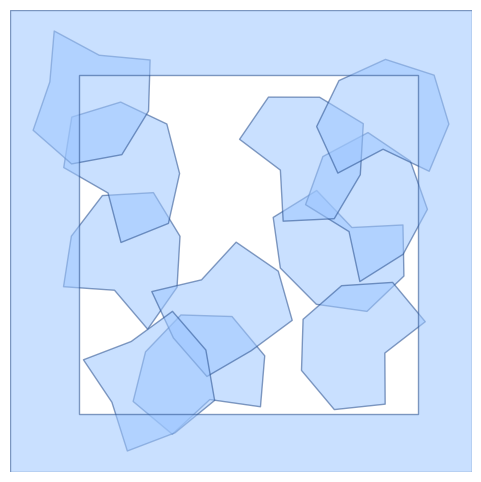

In [2]:
N = 11 # number of squares (eventually)
phiStart = 1.0
phiEnd = (N / records.bestKnownSide(N)**2) * 1.02 # Make it 2% denser than the optimum
wallStiffness = 100
excess = 1e-6

packing = pp.Model(N = N, n = 8, seed = 42)
packing.generateEquilateralPolygons(phi = phiStart, kappa = 4)
packing.syncTargetAreas()
packing.syncTargetPerimeters()
# We want finite boundary conditions:
packing.addShape(np.array([[0, 0], [0, 1], [1, 1], [1, 0]]))
packing.pinVertices(np.arange(packing.getNumVertices())[-4:])
packing.setBoundaryConditions("fixed")
# We want to constrain the edges and areas
packing.setConstraints(area = True, edge = True)
packing.draw()
plt.show()

## We start by minimizing with respect to the overlap area

FIRE (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

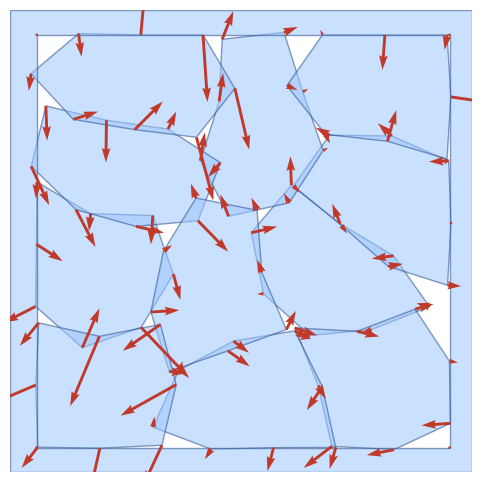

In [3]:
packing.minimizeFIRE(maxSteps = 1000, maxUnbalancedForce = 7e-3, progressBar = True)
packing.draw(forces = packing.getForces())
plt.show()

However, for squares we don't want overlap area, but depth will work.

Additionally, we need the walls to be stiff so we can set that:

In [4]:
packing.setModelType("depth")
packing.setContainerStiffness(wallStiffness)

We can then minimize with respect to the depth

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

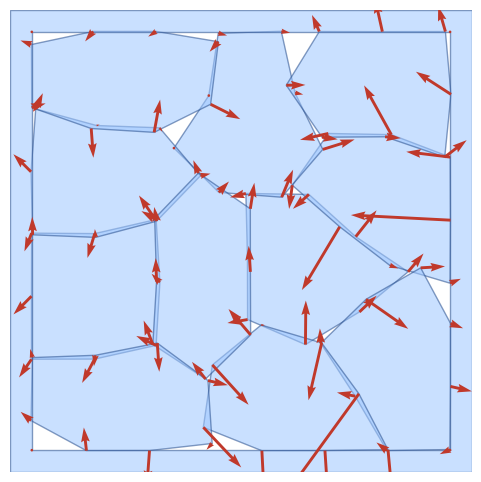

In [5]:
#packing.minimizeFIRE(maxSteps = 1000, maxUnbalancedForce = 1e-7, progressBar = True)
packing.minimizeLBFGS(maxSteps = 1000, maxUnbalancedForce = 1e-10, progressBar = True)
packing.draw(forces = packing.getForces())
plt.show()

## Next we need to get the excess energy down to the value set as "excess"

  hold     phi 1.000000  excess 1.0376e-04  (target 1.0000e-06)  pairOverlap 2.624e-02
  hold     phi 0.952381  excess 3.3729e-08  (target 1.0000e-06)  pairOverlap 9.851e-04
  hold     phi 0.975900  excess 1.2521e-05  (target 1.0000e-06)  pairOverlap 1.180e-02
  hold     phi 0.964069  excess 1.6678e-06  (target 1.0000e-06)  pairOverlap 5.462e-03
  hold     phi 0.961089  excess 7.5626e-07  (target 1.0000e-06)  pairOverlap 3.994e-03
  hold     phi 0.962141  excess 1.0209e-06  (target 1.0000e-06)  pairOverlap 4.504e-03


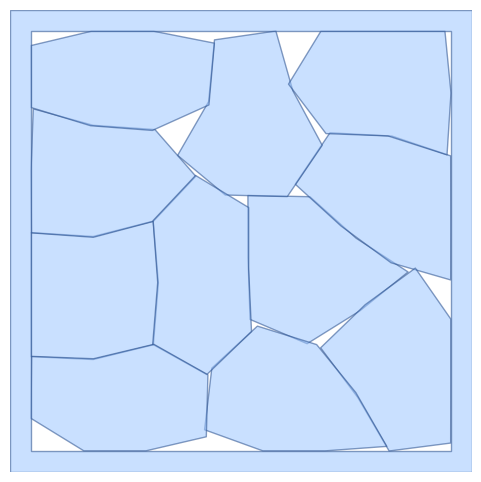

In [6]:
packing.holdExcessEnergy(excess, minimizer = "lbfgs", verbose = True)
packing.draw()
plt.show()

Next we get the distribution of every other diagonal and generate a schedule that will pull these to 0

### We slightly push the target edges toward 2l

In [7]:
numSteps = 18
def getNewTargets(step, numSteps, n):
    positions = packing.getVertices()[:-4].reshape(N, n, 2)
    v1 = positions[:, ::2]
    v2 = np.roll(v1, 1, axis = 1)
    alternatingDiagonals = np.sqrt(np.sum((v2 - v1)**2, axis = 2))
    targetDiagonal = 2 * np.mean(np.sqrt(np.sum((positions - np.roll(positions, 1, axis = 1))**2, axis = 2)))
    return (targetDiagonal - alternatingDiagonals) * step / numSteps + alternatingDiagonals

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.962141  excess 9.1174e-07  (target 3.2000e-07)  pairOverlap 4.390e-03


/home/rdennis/Documents/Code/pyPolygon/model.py:3689: UserWarning: 
*** the requested maxUnbalancedForce 3.00e-11 is within a decade of the noise floor 3.0e-12 ***
    Reachable, but the last decade is mostly roundoff and will cost far more steps than the ones before it.
  threshold = self._convergenceThreshold(maxUnbalancedForce, fThreshold, 1e-9)
/home/rdennis/Documents/Code/pyPolygon/model.py:3729: UserWarning: 
*** the requested maxUnbalancedForce 3.00e-11 is within a decade of the noise floor 3.0e-12 ***
    Reachable, but the last decade is mostly roundoff and will cost far more steps than the ones before it.
  threshold = self._convergenceThreshold(maxUnbalancedForce, fThreshold, 1e-9)


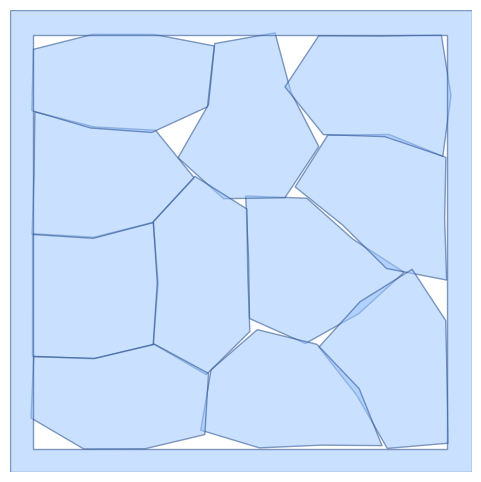

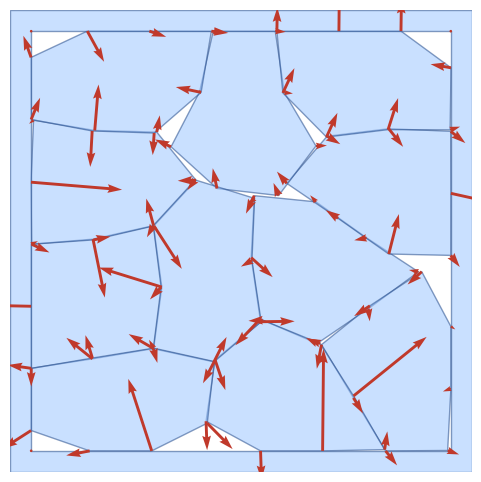

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.962141  excess 2.5277e-06  (target 3.2000e-07)  pairOverlap 5.824e-03


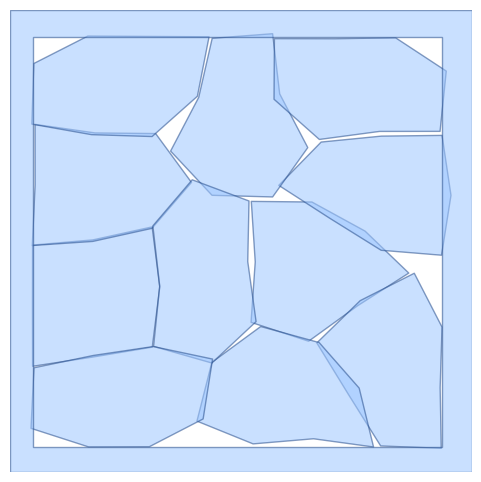

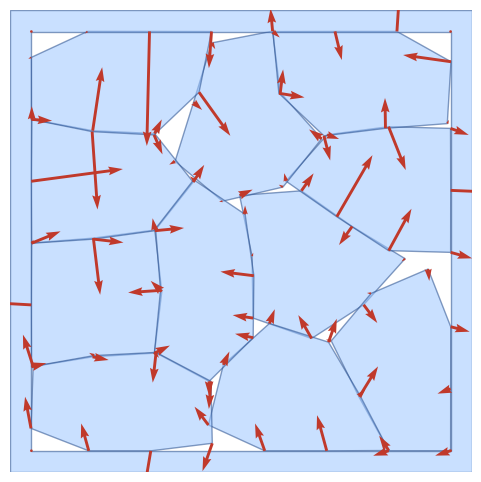

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.962141  excess 1.3695e-06  (target 3.2000e-07)  pairOverlap 6.080e-03


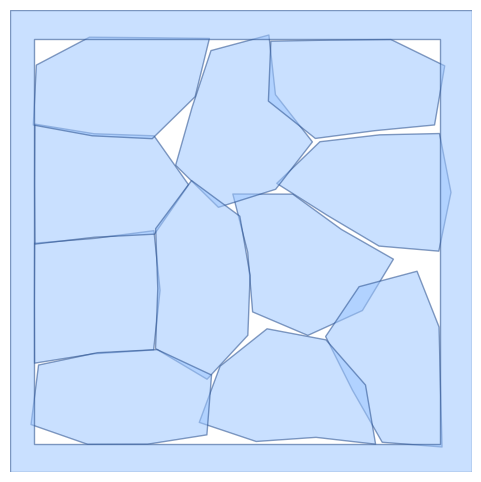

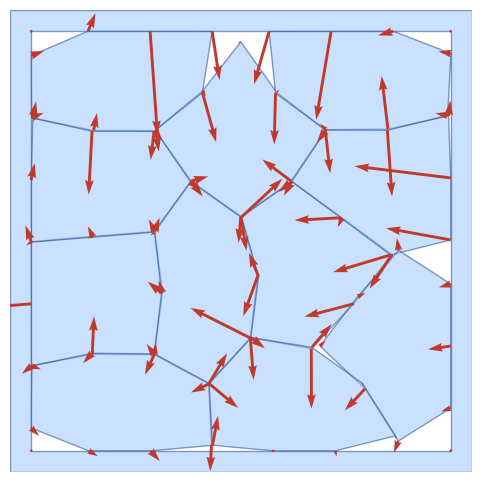

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.962141  excess 1.4924e-05  (target 3.2000e-07)  pairOverlap 1.318e-02
  hold     phi 0.916325  excess 2.9309e-06  (target 3.2000e-07)  pairOverlap 2.057e-03


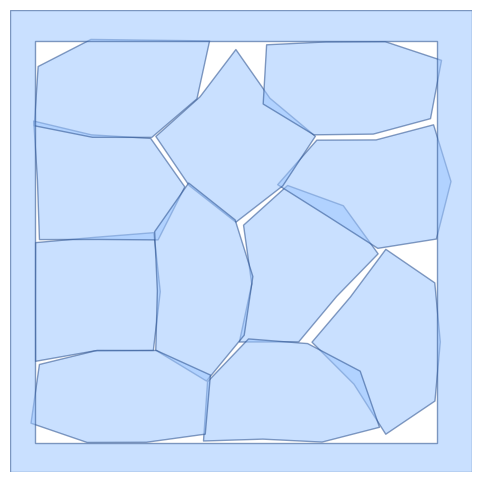

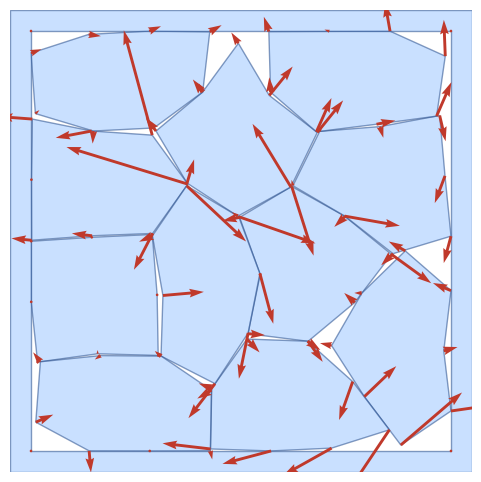

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.916325  excess 7.5113e-12  (target 3.2000e-07)  pairOverlap 6.061e-06
  hold     phi 0.962141  excess 1.0515e-04  (target 3.2000e-07)  pairOverlap 2.345e-02
  hold     phi 0.938953  excess 4.5928e-06  (target 3.2000e-07)  pairOverlap 6.265e-03


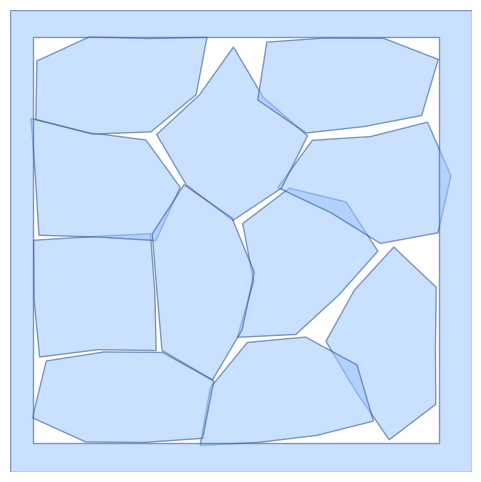

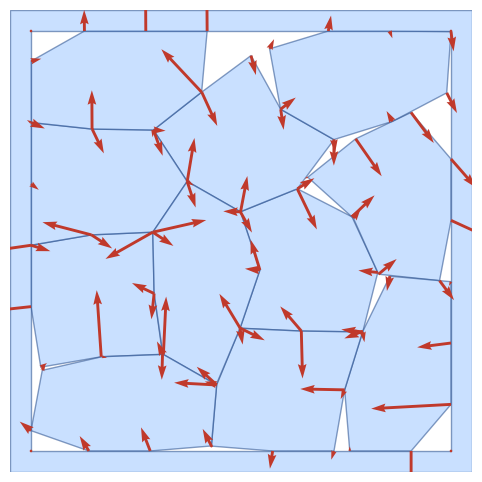

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.938953  excess 8.6518e-06  (target 3.2000e-07)  pairOverlap 8.676e-03


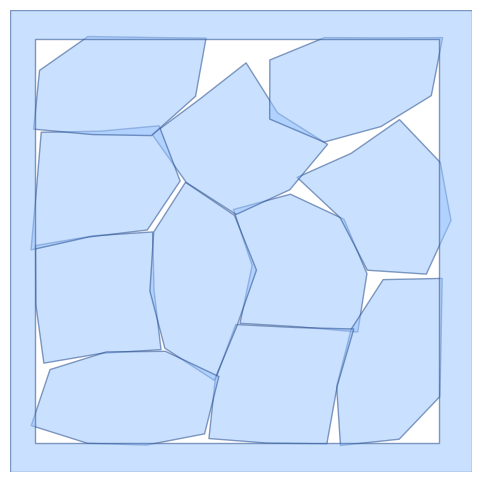

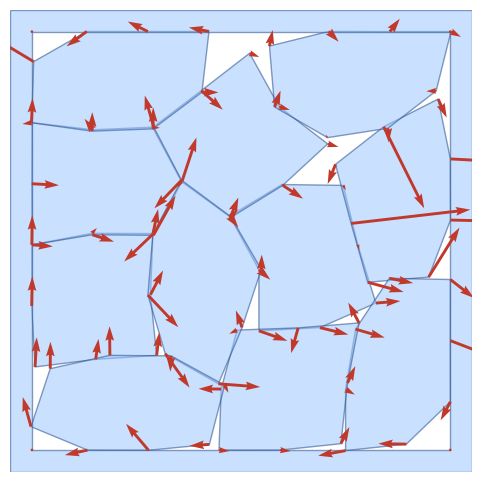

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.938953  excess 7.9363e-05  (target 3.2000e-07)  pairOverlap 1.992e-02
  hold     phi 0.894241  excess 1.6488e-06  (target 3.2000e-07)  pairOverlap 2.321e-03


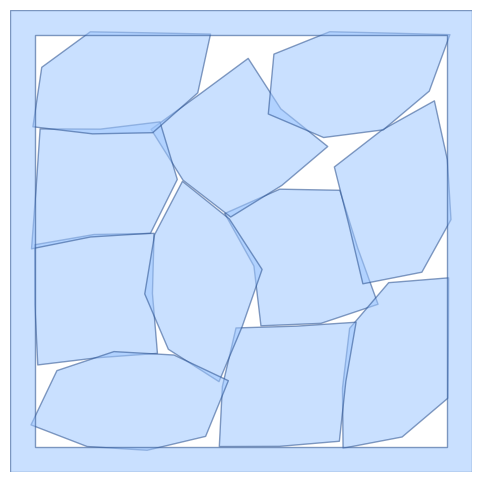

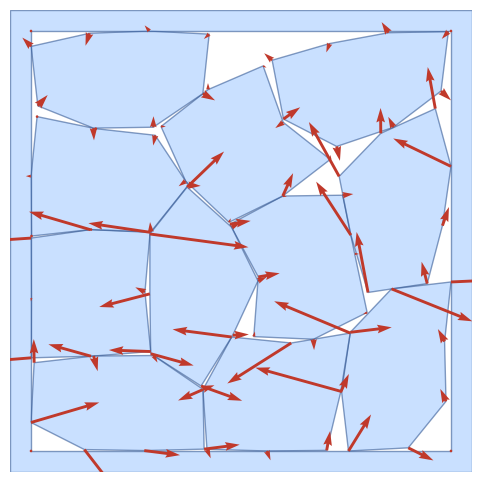

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.894241  excess 1.4916e-11  (target 3.2000e-07)  pairOverlap 1.903e-05
  hold     phi 0.938953  excess 2.1351e-03  (target 3.2000e-07)  pairOverlap 5.402e-02
  hold     phi 0.916325  excess 5.3024e-05  (target 3.2000e-07)  pairOverlap 1.298e-02
  hold     phi 0.896425  excess 4.8210e-06  (target 3.2000e-07)  pairOverlap 3.685e-03


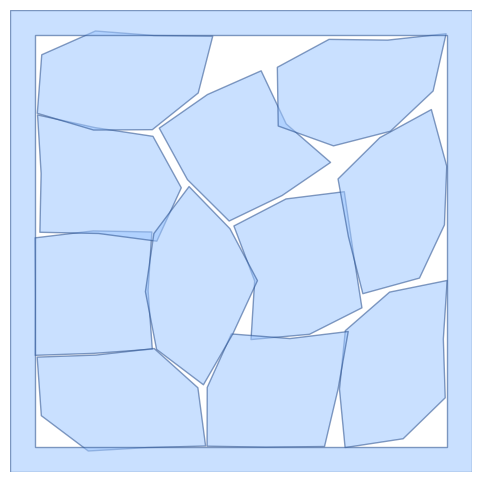

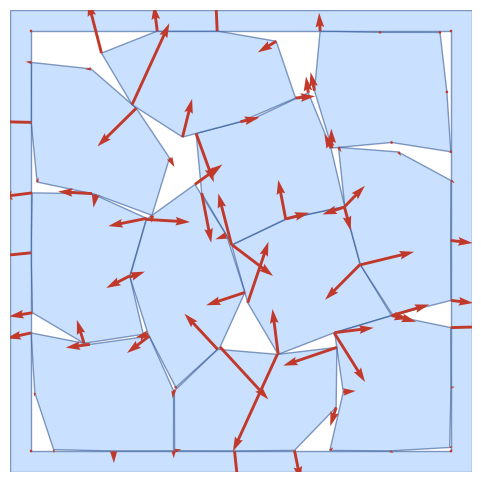

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.896425  excess 9.3440e-06  (target 3.2000e-07)  pairOverlap 6.253e-03


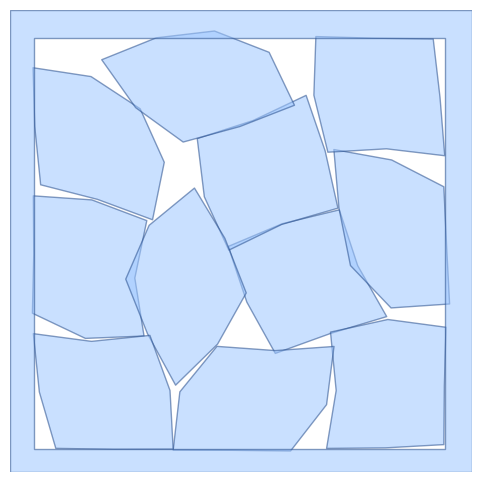

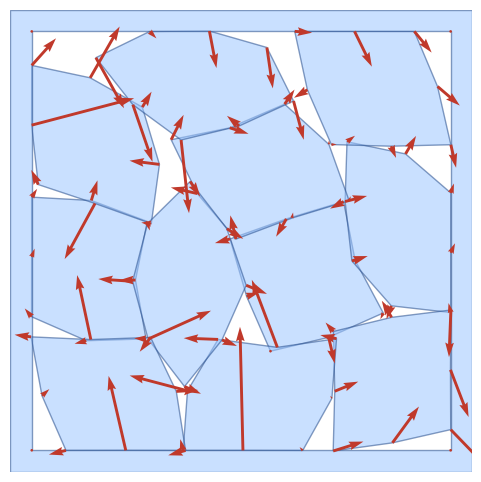

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.896425  excess 7.4201e-05  (target 3.2000e-07)  pairOverlap 1.142e-02
  hold     phi 0.853738  excess 1.5902e-06  (target 3.2000e-07)  pairOverlap 1.337e-03


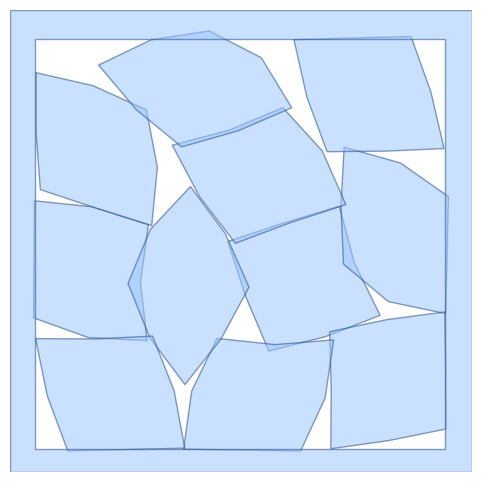

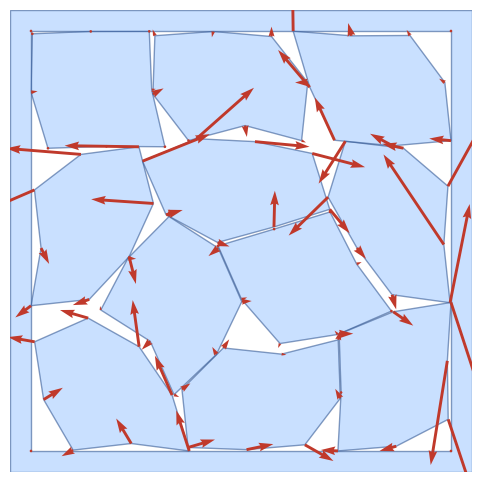

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.853738  excess 1.2226e-11  (target 3.2000e-07)  pairOverlap 3.600e-06


/home/rdennis/Documents/Code/pyPolygon/minimize.py:677: UserWarning: 
*** moment retraction did not converge ***
    residual 1.472e-02 after 90 passes (tolerance 1.0e-12); conditioning 1.00e+00 across 1 rows.
    The per-object constraints ARE still satisfied, so the geometry is valid -- it is the moment TARGETS that were not reached.

    STOPPED EARLY, after 90 passes: the residual went 8 consecutive passes without falling by 1%, which is what an unreachable target looks like from the inside. The remaining budget is not being spent, because it would be charged once per MINIMIZER STEP and buys nothing. Repeats from this constraint set are suppressed.
  _retract(constraints, packing, shakeTol, shakeMaxIter)


KeyboardInterrupt: 

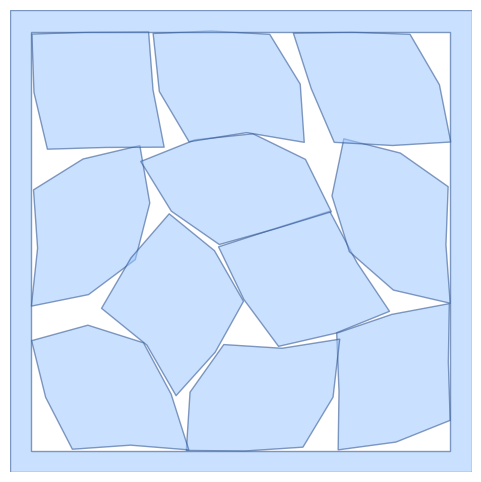

In [8]:
# We constrain these diagonals:
packing.setConstraints(edge = True, area = True, alternatingDiagonal = [1])
for step in range(1, numSteps + 1):
    packing.updateAlternatingDiagonals(targets = getNewTargets(step, numSteps, 8))
    packing.setModelType("depth")
    packing.setConstraints(edge = True, area = True, alternatingDiagonal = [1])
    packing.draw(forces = packing.getForces())
    packing.minimizeLBFGS(maxSteps = 1000, maxUnbalancedForce = 1e-10, progressBar = True)
    packing.holdExcessEnergy(3.2e-7, tolerance = 3.4,
                             maxUnbalancedForce = 1e-6, maxSteps = 2000,
                             minimizer = "lbfgs", verbose = True)
    packing.minimizeFireLBFGS(maxUnbalancedForce = 3e-11)
    packing.draw(forces = packing.getForces())
    plt.show()

In [9]:
np.std(getNewTargets(0, numSteps, 8))

0.00515664231580674

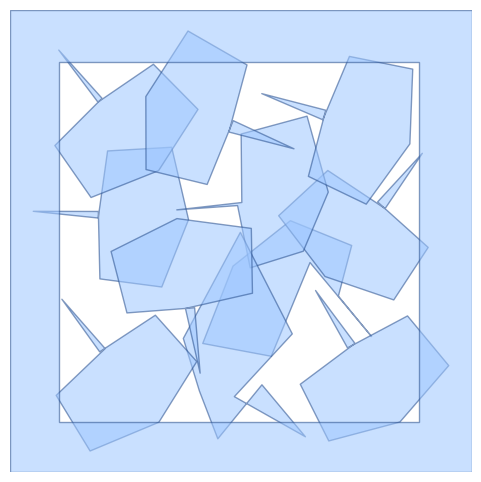

In [ ]:
packing.draw()
plt.show()
packing.setModelType("sharp")
packing.minimizeFIRE(maxSteps = 2000, maxUnbalancedForce = 1e-3)
packing.draw()
plt.show()